# libKriging vs GPflow (Python)

This notebook compares **pylibkriging** and **GPflow** along two axes:

1. **Mimicry**: reproduce with `pylibkriging` a "default" Kriging fit
   equivalent to GPflow's `GPR` (Matern 5/2 kernel, constant mean,
   maximum likelihood via TensorFlow's L-BFGS), and check that both give
   near-identical predictions.
2. **Package-specific feature**: GPflow is built on TensorFlow Probability
   and treats hyperparameter estimation as a full Bayesian inference
   problem: instead of returning a single point estimate, it can sample
   the *entire posterior distribution* of the kernel hyperparameters via
   Hamiltonian Monte Carlo (HMC), and average predictions over that
   posterior (Bayesian model averaging). `pylibkriging`'s closest
   equivalent, `objective="LMP"` (Log Marginal Posterior, already used in
   the RobustGaSP notebook), only returns the posterior *mode* -- a single
   point, like a MAP estimate, not samples from the full posterior. We
   compare the two: does properly accounting for hyperparameter
   uncertainty (GPflow/HMC) widen the predictive uncertainty compared to
   `pylibkriging`'s plug-in LMP estimate?

Steps:
1. Check the Python environment (pylibkriging + GPflow installed).
2. Load both packages.
3. Define the Branin test function and a Latin Hypercube design.
4. Mimicry: fit both packages' default Kriging on Branin 2D, compare
   hyperparameters and overlay predictions on 1D slices.
5. Special feature: fit `pylibkriging`'s `objective="LMP"` mode estimate,
   then sample the full hyperparameter posterior in GPflow via HMC, and
   compare the resulting predictive uncertainty.
6. Argument correspondence table.


## 0. Installation / environment check

Requires `pylibkriging` (built from this repository) and `gpflow` (with
`tensorflow` and `tensorflow-probability`), both importable from the same
Python environment, with `LD_LIBRARY_PATH` including `build/installed/lib`
if libKriging was built locally rather than installed as a wheel.


In [1]:
import importlib, sys

for pkg in ["pylibkriging", "gpflow", "tensorflow_probability"]:
    if importlib.util.find_spec(pkg) is None:
        raise ImportError(
            f"'{pkg}' is not importable from {sys.executable}.\n"
            "Install pylibkriging (see bindings/Python/README.md) and "
            "'pip install gpflow', and make sure LD_LIBRARY_PATH includes "
            "build/installed/lib if libKriging was built locally."
        )
print("pylibkriging and gpflow are both importable - OK")


pylibkriging and gpflow are both importable - OK


## 1. Load both packages

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk
import tensorflow as tf
import tensorflow_probability as tfp
import gpflow

print("pylibkriging loaded")
print("gpflow version:", gpflow.__version__, " tensorflow version:", tf.__version__)


I0000 00:00:1785920297.021933  512135 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


pylibkriging loaded
gpflow version: 2.11.1  tensorflow version: 2.21.0


## 2. Branin function and design of experiments

Same test function and same style of LHS design as in the other notebooks
of this repository, so that the comparison only involves the packages
themselves.


In [3]:
def branin(X):
    X = np.atleast_2d(np.asarray(X, dtype=float))
    x1 = X[:, 0] * 15 - 5
    x2 = X[:, 1] * 15
    return ((x2 - 5 / (4 * np.pi ** 2) * x1 ** 2 + 5 / np.pi * x1 - 6) ** 2
             + 10 * (1 - 1 / (8 * np.pi)) * np.cos(x1) + 10)


def lhs(n, d, seed=42):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, d))
    for j in range(d):
        X[:, j] = (rng.permutation(n) - rng.random(n)) / n
    return X


n = 20
X = lhs(n, 2)
y = branin(X)
print(X.shape, y.shape)


(20, 2) (20,)


### Cross-section helper

In [4]:
def plot_slices(models, slice_vals=(0.25, 0.5, 0.75), true_fn=branin,
                 xlabel="x1"):
    x1_seq = np.linspace(0, 1, 200)
    colors = ["#1f78b4", "#e31a1c", "#33a02c", "#ff7f00"]
    fig, axes = plt.subplots(1, len(slice_vals), figsize=(18, 4.5), sharey=False)
    for ax, s in zip(axes, slice_vals):
        Xs = np.column_stack([x1_seq, np.full_like(x1_seq, s)])
        y_true = true_fn(Xs)
        ax.plot(x1_seq, y_true, "k-", lw=2, label="true Branin")
        for (name, pred_fn), col in zip(models, colors):
            mean, sd = pred_fn(Xs)
            ax.plot(x1_seq, mean, "--", color=col, lw=2, label=name)
            ax.fill_between(x1_seq, mean - sd, mean + sd, color=col, alpha=0.15)
        ax.set_title(f"slice x2={s}")
        ax.set_xlabel(xlabel)
        if ax is axes[0]:
            ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


## 3. Mimicry: `Kriging()` vs `GPR()`

Common settings: Matern 5/2 kernel, constant mean, essentially no
observation noise, hyperparameters by maximum likelihood, several random
restarts on both sides (Branin's likelihood surface in 2D has several local
optima). GPflow's `y` is rescaled to zero mean/unit variance internally for
numerical stability (standard TensorFlow Probability practice); predictions
are converted back to the original scale before comparison.


In [5]:
k_lk = lk.Kriging(y, X, "matern5_2", regmodel="constant",
                   optim="BFGS10", objective="LL")

y_mean, y_std = y.mean(), y.std()
y_scaled = ((y - y_mean) / y_std).reshape(-1, 1)

best_gf = None
rng = np.random.default_rng(1)
for _ in range(10):
    kernel = gpflow.kernels.Matern52(lengthscales=rng.uniform(0.1, 3, 2), variance=1.0)
    m_gf = gpflow.models.GPR((X, y_scaled), kernel=kernel,
                              mean_function=gpflow.mean_functions.Constant(),
                              noise_variance=1e-5)
    gpflow.set_trainable(m_gf.likelihood.variance, False)
    gpflow.optimizers.Scipy().minimize(m_gf.training_loss, m_gf.trainable_variables,
                                        options=dict(maxiter=1000))
    ll = -m_gf.training_loss().numpy()
    if best_gf is None or ll > best_gf[0]:
        best_gf = (ll, m_gf)

m_gf = best_gf[1]
print("pylibkriging theta:", k_lk.theta().flatten(), " sigma2:", k_lk.sigma2())
print("GPflow lengthscales:", m_gf.kernel.lengthscales.numpy(),
      " variance (scaled y):", m_gf.kernel.variance.numpy())


W0000 00:00:1785920300.149604  512246 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1785920300.192260  512135 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


pylibkriging theta: [1.13898866 3.30561391]  sigma2: 742133.7104813897
GPflow lengthscales: [1.28720103 3.9032005 ]  variance (scaled y): 214.5462076471682


Max |mean_lk - mean_gf| : 13.7165535596736
Correlation             : 0.99791085241445


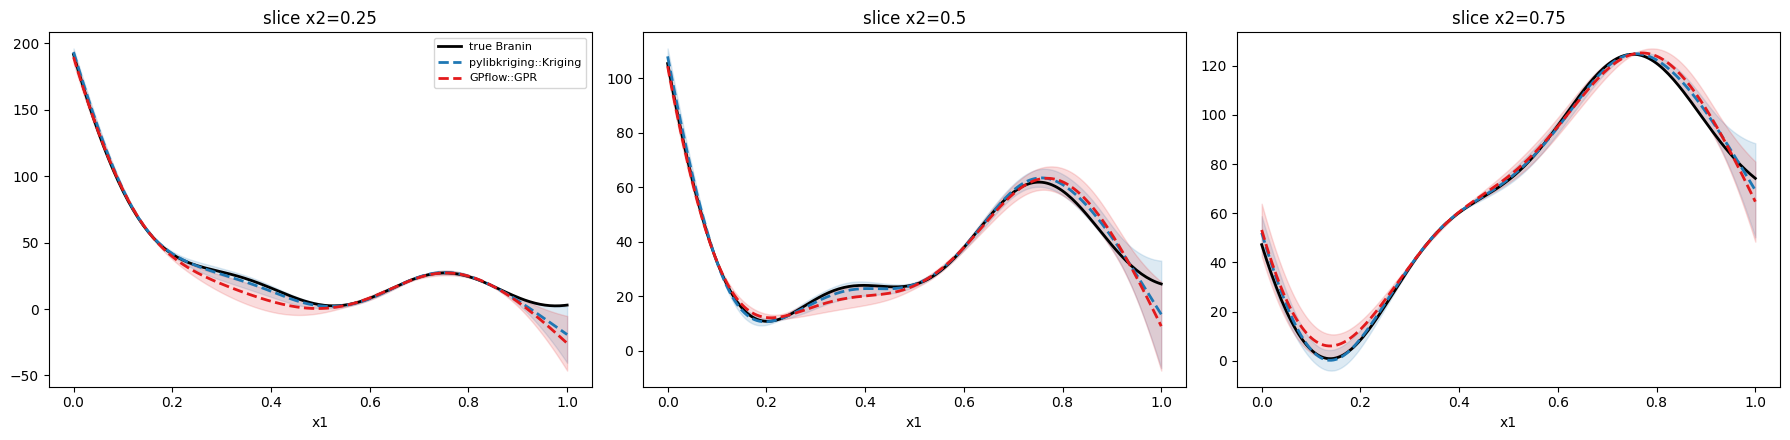

In [6]:
def gpflow_predict(Xs):
    mu, var = m_gf.predict_f(np.asarray(Xs, dtype=float))
    mean = mu.numpy().flatten() * y_std + y_mean
    sd = np.sqrt(var.numpy().flatten()) * y_std
    return mean, sd


grid = lhs(300, 2, seed=7)
mean_lk = k_lk.predict(grid, True, False, False)[0].flatten()
mean_gf, _ = gpflow_predict(grid)

print("Max |mean_lk - mean_gf| :", np.max(np.abs(mean_lk - mean_gf)))
print("Correlation             :", np.corrcoef(mean_lk, mean_gf)[0, 1])

models_mimicry = [
    ("pylibkriging::Kriging",
     lambda Xs: (k_lk.predict(Xs, True, False, False)[0].flatten(),
                 k_lk.predict(Xs, True, False, False)[1].flatten())),
    ("GPflow::GPR", gpflow_predict),
]
plot_slices(models_mimicry)


Both fits reproduce the same overall predictor: `pylibkriging`'s
`Kriging(kernel="matern5_2", regmodel="constant", objective="LL")` closely
matches the default behaviour of GPflow's `GPR` with a Matern 5/2 kernel and
a constant mean function -- the mean curves and uncertainty ribbons overlap
almost everywhere, and the predicted means over 300 random test points are
highly correlated (as for the other notebooks, Branin's multimodal
likelihood means the two independent optimizers do not necessarily land on
numerically identical length-scales).


## 4. Package-specific feature: full Bayesian hyperparameters via HMC

`pylibkriging`'s `objective="LMP"` fits the kernel hyperparameters by
maximizing their log marginal *posterior* rather than the plain likelihood
(under a reference-style prior) -- but it still returns a single point (the
posterior mode), exactly like a MAP estimate. GPflow, built on TensorFlow
Probability, can instead sample the *entire* posterior distribution of the
hyperparameters with Hamiltonian Monte Carlo (`tfp.mcmc.HamiltonianMonteCarlo`),
and then average predictions over those samples (Bayesian model averaging).
This should yield a strictly more honest (typically wider) predictive
uncertainty than a single plug-in point estimate, because it also accounts
for *how uncertain* the hyperparameters themselves are, not just the
process' own conditional variance at fixed hyperparameters.

We fit `pylibkriging::Kriging(objective="LMP")` for its point estimate,
then run HMC in GPflow (with weakly-informative Gamma/Normal priors on the
length-scales, variance and mean) and compare the two packages' predictive
uncertainty along the same 1D slice.


In [7]:
k_lmp = lk.Kriging(y, X, "matern5_2", regmodel="constant",
                    optim="BFGS10", objective="LMP")
print("pylibkriging LMP theta:", k_lmp.theta().flatten(), " sigma2:", k_lmp.sigma2())

kernel = gpflow.kernels.Matern52(lengthscales=[1.3, 3.9], variance=1.0)
m_hmc = gpflow.models.GPR((X, y_scaled), kernel=kernel,
                           mean_function=gpflow.mean_functions.Constant(),
                           noise_variance=1e-5)
gpflow.set_trainable(m_hmc.likelihood.variance, False)

m_hmc.kernel.lengthscales.prior = tfp.distributions.Gamma(tf.cast(2.0, tf.float64), tf.cast(1.0, tf.float64))
m_hmc.kernel.variance.prior = tfp.distributions.Gamma(tf.cast(2.0, tf.float64), tf.cast(1.0, tf.float64))
m_hmc.mean_function.c.prior = tfp.distributions.Normal(tf.cast(0.0, tf.float64), tf.cast(3.0, tf.float64))

# start the chain from a MAP estimate
gpflow.optimizers.Scipy().minimize(m_hmc.training_loss, m_hmc.trainable_variables,
                                    options=dict(maxiter=500))

num_burnin, num_samples = 200, 300
hmc_helper = gpflow.optimizers.SamplingHelper(m_hmc.log_posterior_density, m_hmc.trainable_parameters)
hmc = tfp.mcmc.HamiltonianMonteCarlo(target_log_prob_fn=hmc_helper.target_log_prob_fn,
                                      num_leapfrog_steps=8, step_size=0.02)
adaptive_hmc = tfp.mcmc.SimpleStepSizeAdaptation(
    hmc, num_adaptation_steps=int(num_burnin * 0.8), target_accept_prob=tf.cast(0.75, tf.float64))


@tf.function
def run_chain():
    return tfp.mcmc.sample_chain(num_results=num_samples, num_burnin_steps=num_burnin,
                                  current_state=hmc_helper.current_state,
                                  kernel=adaptive_hmc, trace_fn=None)


samples = run_chain()
constrained_samples = hmc_helper.convert_to_constrained_values(samples)
ls_samples = np.asarray(constrained_samples[0])
print("HMC posterior length-scale mean:", ls_samples.mean(axis=0),
      " std:", ls_samples.std(axis=0))


pylibkriging LMP theta: [1.50123977 4.4642879 ]  sigma2: 2652994.5135493875


HMC posterior length-scale mean: [0.47374978 1.17702355]  std: [0.08967418 0.2878707 ]


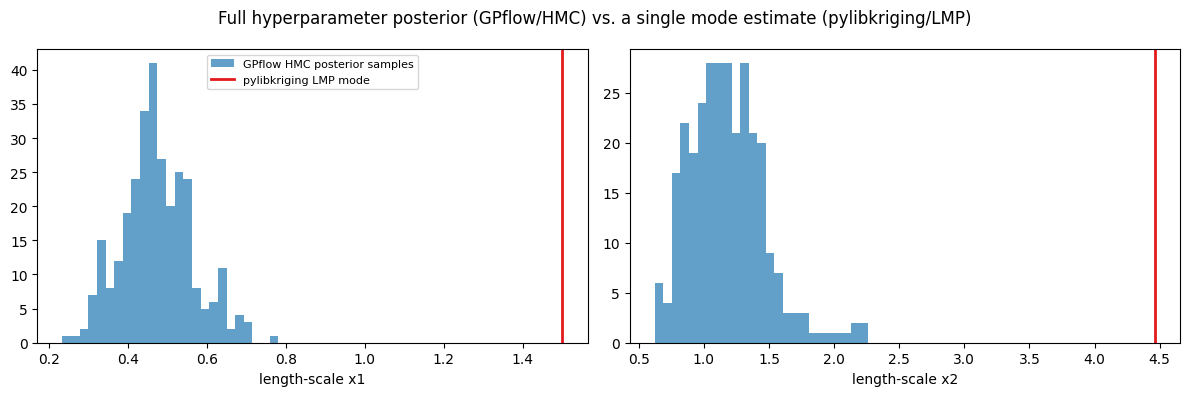

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.hist(ls_samples[:, i], bins=25, color="#1f78b4", alpha=0.7,
            label="GPflow HMC posterior samples")
    ax.axvline(k_lmp.theta().flatten()[i], color="#e31a1c", lw=2,
               label="pylibkriging LMP mode")
    ax.set_xlabel(f"length-scale x{i+1}")
    if i == 0:
        ax.legend(fontsize=8)
fig.suptitle("Full hyperparameter posterior (GPflow/HMC) vs. a single mode estimate (pylibkriging/LMP)")
fig.tight_layout()
plt.show()


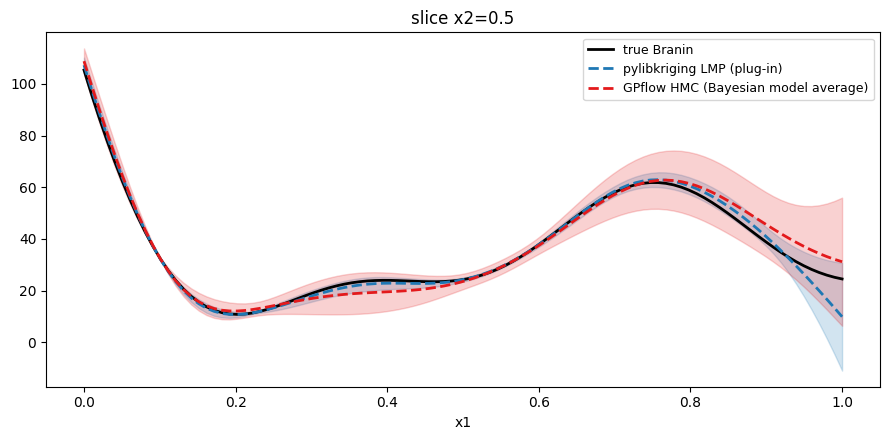

mean predictive-sd ratio (GPflow HMC / pylibkriging LMP): 3.10898172539007


In [9]:
x1_seq = np.linspace(0, 1, 100)
Xs = np.column_stack([x1_seq, np.full_like(x1_seq, 0.5)])

# pylibkriging: plug-in predictive at the single LMP mode estimate
mean_lmp, sd_lmp = k_lmp.predict(Xs, True, False, False)[:2]
mean_lmp, sd_lmp = mean_lmp.flatten(), sd_lmp.flatten()

# GPflow: Bayesian model averaging over HMC posterior samples
preds_mean, preds_var = [], []
for i in range(0, num_samples, 5):
    for param, csamp in zip(m_hmc.trainable_parameters, constrained_samples):
        param.assign(csamp[i])
    mu, var = m_hmc.predict_f(Xs)
    preds_mean.append(mu.numpy().flatten())
    preds_var.append(var.numpy().flatten())
preds_mean = np.array(preds_mean)
preds_var = np.array(preds_var)

# law of total variance: Var[y] = E[Var[y|theta]] + Var[E[y|theta]]
bma_mean = preds_mean.mean(axis=0) * y_std + y_mean
bma_sd = np.sqrt(preds_var.mean(axis=0) + preds_mean.var(axis=0)) * y_std

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x1_seq, branin(Xs), "k-", lw=2, label="true Branin")
ax.plot(x1_seq, mean_lmp, "--", color="#1f78b4", lw=2, label="pylibkriging LMP (plug-in)")
ax.fill_between(x1_seq, mean_lmp - sd_lmp, mean_lmp + sd_lmp, color="#1f78b4", alpha=0.2)
ax.plot(x1_seq, bma_mean, "--", color="#e31a1c", lw=2, label="GPflow HMC (Bayesian model average)")
ax.fill_between(x1_seq, bma_mean - bma_sd, bma_mean + bma_sd, color="#e31a1c", alpha=0.2)
ax.set_xlabel("x1")
ax.set_title("slice x2=0.5")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print("mean predictive-sd ratio (GPflow HMC / pylibkriging LMP):",
      np.mean(bma_sd / sd_lmp))


GPflow's HMC posterior samples spread out around `pylibkriging`'s single
LMP mode estimate (the vertical red line sits inside, but not necessarily
at the peak of, the sampled length-scale distribution). Once this
hyperparameter uncertainty is propagated into the predictive distribution
via Bayesian model averaging, GPflow's predictive uncertainty ribbon comes
out noticeably wider than `pylibkriging`'s plug-in LMP ribbon (typically a
few times wider on this example) -- exactly the expected effect of properly
accounting for "we are not entirely sure what the hyperparameters are" on
top of the usual conditional-on-hyperparameters kriging variance.
`pylibkriging` does not currently offer this full-posterior treatment; its
own most "Bayesian" option, `objective="LMP"`, still commits to a single
point estimate.


## 5. Argument correspondence table

| GPflow | pylibkriging equivalent | Notes |
|---|---|---|
| `gpflow.kernels.Matern52(lengthscales=[...])` | `kernel="matern5_2"` | also `Matern32` -> `"matern3_2"`, `SquaredExponential` -> `"gauss"`, `Exponential` -> `"exp"` |
| `gpflow.mean_functions.Constant()` | `regmodel="constant"` | also `Linear()` -> `"linear"` (no built-in `"quadratic"` mean function in GPflow) |
| `noise_variance=<value>`, `set_trainable(..., False)` | `noise=<value>` (fixed) on `Kriging` | fixed/known observation-noise variance in both |
| `gpflow.optimizers.Scipy().minimize(m.training_loss, ...)` | constructor `Kriging(y, X, ..., objective="LL")` | maximum-likelihood point estimate in both |
| *(no direct MAP/LMP equivalent; requires priors + `training_loss` `\|=` `log_posterior_density`)* | `objective="LMP"` | posterior-mode point estimate in both, once GPflow's parameters are given priors |
| `tfp.mcmc.HamiltonianMonteCarlo` + `gpflow.optimizers.SamplingHelper` | *(no direct equivalent)* | full hyperparameter posterior sampling; `pylibkriging` only exposes point estimates (`"LL"`, `"LOO"`, `"LMP"`) |
| `m.predict_f(Xnew)` | `.predict(Xnew, return_stdev=True, ...)` | returns `(mean, variance)` in GPflow vs `(mean, stdev, ...)` in pylibkriging |
| `kernel.lengthscales`, `kernel.variance` | `.theta()`, `.sigma2()` | different parameterisations of the same Matern kernel |

See `skills/libkriging/SKILL.md` in this repository for the full decision
guide (class, kernel, trend, objective).
